In [72]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt
import requests
from shapely.geometry import shape
from shapely.geometry import Polygon, LineString, MultiLineString, MultiPolygon
from shapely.ops import polygonize, unary_union
import os
import rasterio
from shapely.geometry import box
%matplotlib inline
pd.set_option('display.max_columns', None)  # Show all columns

from scipy.stats import gmean

In [2]:
parks_dataset_iteration2 = gpd.read_file("natural_assets_data_raw/parks_dataset_iteration2.gpkg")

I buffer the areas to include areas nearby.

In [3]:
assets_buffered = parks_dataset_iteration2.copy()
assets_buffered["geometry"] = assets_buffered.geometry.buffer(1000)

In [4]:
uk_boundaries = gpd.read_file("natural_assets_data_raw/uk_boundaries.gpkg")
uk_union = uk_boundaries.union_all()
if isinstance(uk_union, MultiPolygon):
    largest_poly = max(uk_union.geoms, key=lambda x: x.area)
else:
    largest_poly = uk_union

buffered_poly = largest_poly.buffer(200)
uk_largest_polygon = gpd.GeoDataFrame(geometry=[buffered_poly], crs=uk_boundaries.crs)
mainland_geom = uk_largest_polygon.union_all()

In [5]:
parks_dataset_iteration2

,name,website,wikidata,geometry
0,Drum Sands,None,None,"MULTIPOLYGON (((320716.603 677076.823, 320669...."
1,Sand Bay,None,Q7415759,"MULTIPOLYGON (((332780.459 163169.415, 332778...."
2,Porth Beach,None,None,"MULTIPOLYGON (((182991.884 62699.151, 182959.3..."
3,Watergate Beach,None,Q7974111,"MULTIPOLYGON (((183311.411 63810.319, 183313.3..."
4,Mawgan Porth,None,None,"MULTIPOLYGON (((184587.52 68016.794, 184601.92..."
...,...,...,...,...
7723,Ynys Uchaf,None,None,"MULTIPOLYGON (((249265.191 214975.422, 249263...."
7724,Yr Arddu,None,None,"MULTIPOLYGON (((263629.5 346584, 263629.5 3465..."
7725,Yr Eifl,None,None,"MULTIPOLYGON (((237415.731 344280.06, 237434.3..."
7726,Ysbyty Bron y Garth,None,None,"MULTIPOLYGON (((260008.979 338445.14, 260014.9..."


In [6]:
def get_number_overlapped(assets_dataset, target_dataset, target_colname: str):
    # Copy and rename geometry column in target to preserve it
    # Spatial join: which points fall inside which assets
    joined = gpd.sjoin(target_dataset, assets_dataset, predicate="within")
    counts = joined.groupby("index_right").size()
    assets_dataset[target_colname] = assets_dataset.index.map(counts).fillna(0)
    
    # scale
    min_val, max_val = assets_dataset[target_colname].min(), assets_dataset[target_colname].max()
    assets_dataset[f"scaled_{target_colname}"] = (
        (assets_dataset[target_colname] - min_val) / (max_val - min_val)
        if max_val != min_val else 0
    )
    return assets_dataset

In [7]:
def get_length_overlapped(assets_dataset, target_dataset, target_colname: str):
    # Copy and rename geometry column in target to preserve it
    target_copy = assets_dataset.copy()
    target_copy = target_copy.rename(columns={"geometry": "asset_geometry"})
    target_copy = target_copy.set_geometry("asset_geometry")

    # Perform spatial join
    joined = gpd.sjoin(target_copy, target_dataset, predicate='intersects')
    joined["asset_index"] = joined.index

    # Extract intersecting geometries
    joined["path_geometry"] = joined["index_right"].map(target_dataset.geometry)
    joined["intersection_len"] = joined.geometry.intersection(joined["path_geometry"]).length

    # Group and assign total length
    lengths = joined.groupby("asset_index")["intersection_len"].sum()
    assets_dataset[target_colname] = assets_dataset.index.map(lengths).fillna(0)

    # Compute and scale density
    # assets_dataset[f"density_{target_colname}"] = assets_dataset[target_colname] / assets_dataset.geometry.area
    # col = f"density_{target_colname}"
    col = target_colname
    min_val, max_val = assets_dataset[col].min(), assets_dataset[col].max()
    assets_dataset[f"scaled_{target_colname}"] = (
        (assets_dataset[col] - min_val) / (max_val - min_val)
        if max_val != min_val else 0
    )

    return assets_dataset

In [276]:
def calc_gmean_nozeros(dfs, target_df, colname: str, eps=0.01): #eps=1e-6
    dfs_no_zeros = dfs + eps
    target_df[colname] = dfs_no_zeros.apply(gmean, axis=1)
    print(f"Calculated geometric mean for {dfs.columns.tolist()}")
    return target_df

# Loading the supporting datasets

In [8]:
cave = gpd.read_file("natural_assets_data_raw/cave.gpkg")

In [9]:
with rasterio.open("natural_assets_data_raw/georichness/georichness.tif") as src:
    print(src.profile)  # Metadata
    georichness = src.read()  # Reads all bands as a 3D array (bands, rows, cols)

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 425, 'height': 700, 'count': 1, 'crs': CRS.from_epsg(27700), 'transform': Affine(2010.4202204705882, 0.0, -99739.3611,
       0.0, -2012.5310397142857, 1318070.6636), 'blockysize': 19, 'tiled': False, 'interleave': 'band'}


## Overall biodiversity

In [10]:
ecological_status = pd.read_csv("natural_assets_data_raw/ecological_status/data/EcologicalStatusMap_V2.csv")

In [11]:
def make_cell(row):
    return box(row["Easting"], row["Northing"], row["Easting"] + 10000, row["Northing"] + 10000)

ecological_status["geometry"] = ecological_status.apply(make_cell, axis=1)
ecological_status = gpd.GeoDataFrame(ecological_status, geometry="geometry", crs="EPSG:27700") 

In [12]:
ecological_status

,gridSquare,Easting,Northing,dominantLandClass,ecologicalStatus,geometry
0,HP40,440000,1200000,32s,0.396020,"POLYGON ((450000 1200000, 450000 1210000, 4400..."
1,HP50,450000,1200000,32s,0.400247,"POLYGON ((460000 1200000, 460000 1210000, 4500..."
2,HP51,450000,1210000,31s,0.442616,"POLYGON ((460000 1210000, 460000 1220000, 4500..."
3,HP60,460000,1200000,32s,0.421619,"POLYGON ((470000 1200000, 470000 1210000, 4600..."
4,HP61,460000,1210000,32s,0.423650,"POLYGON ((470000 1210000, 470000 1220000, 4600..."
...,...,...,...,...,...,...
2794,TR37,630000,170000,7e,0.785119,"POLYGON ((640000 170000, 640000 180000, 630000..."
2795,TR46,640000,160000,7e,0.772989,"POLYGON ((650000 160000, 650000 170000, 640000..."
2796,TV49,540000,90000,7e,0.824438,"POLYGON ((550000 90000, 550000 100000, 540000 ..."
2797,TV59,550000,90000,2e,0.769718,"POLYGON ((560000 90000, 560000 100000, 550000 ..."


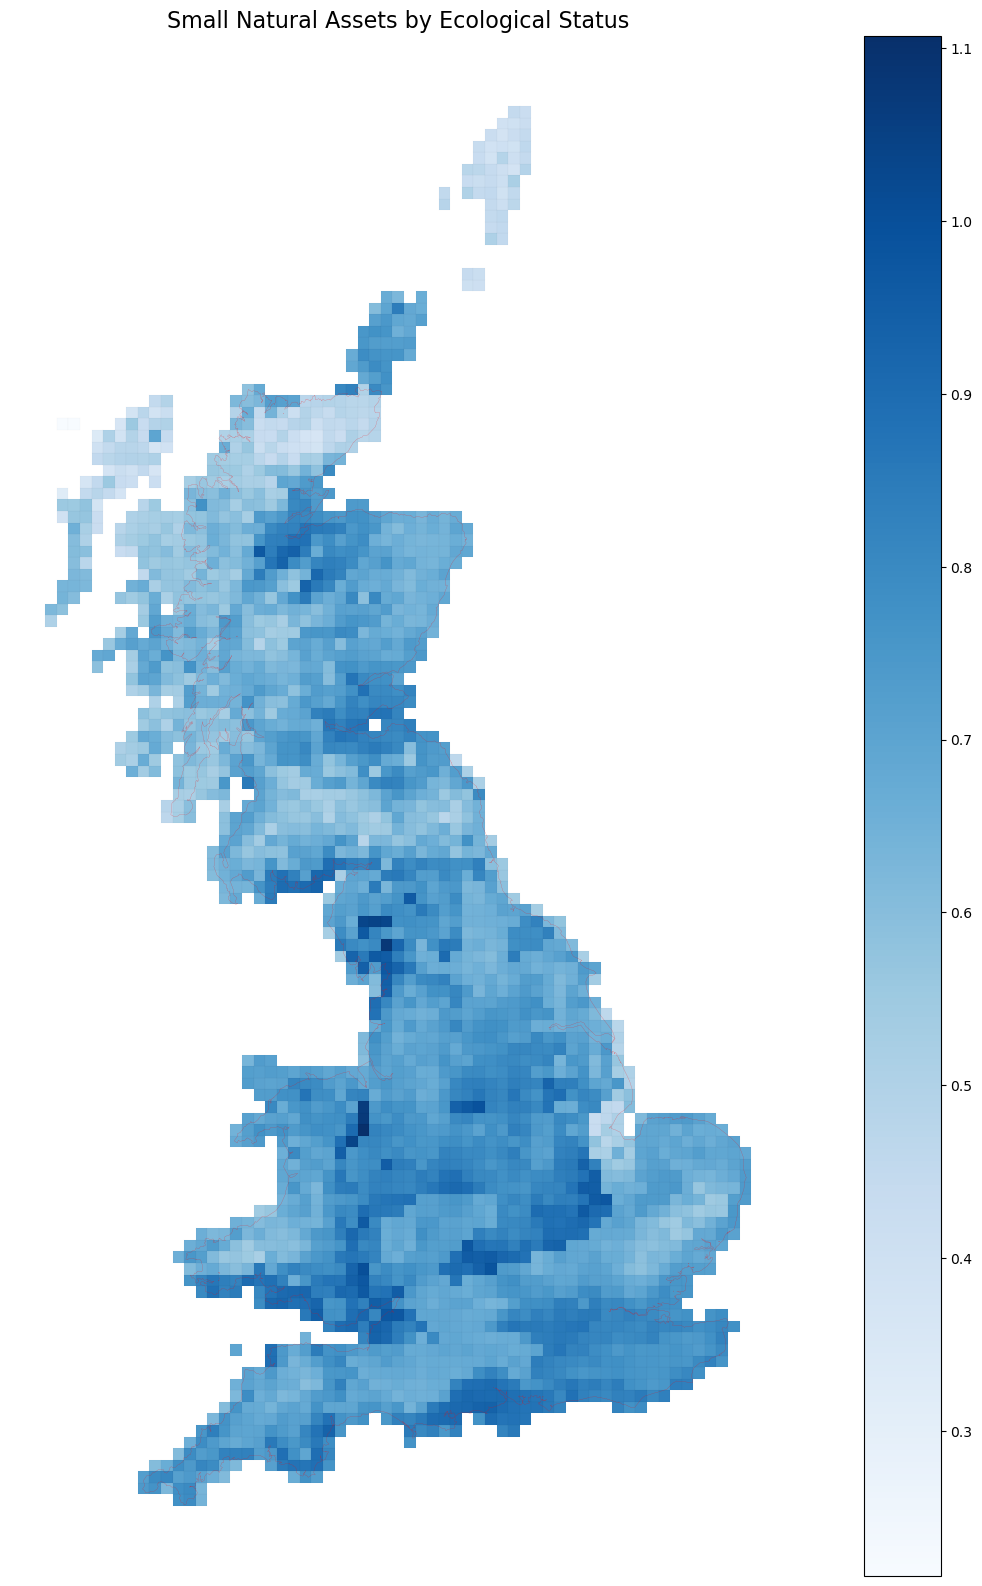

In [13]:
fig, ax = plt.subplots(figsize=(20, 20))

ecological_status.plot(column="ecologicalStatus", ax=ax, cmap="Blues", linewidth=0.01, edgecolor="black", legend=True)
uk_largest_polygon.plot(ax=ax, facecolor="none", linewidth=0.1, edgecolor="red")

plt.title("Small Natural Assets by Ecological Status", fontsize=16)
plt.axis('off')
plt.show()

In [14]:
eco_joined = gpd.sjoin(ecological_status, assets_buffered, predicate="intersects")
eco_max = eco_joined.groupby("index_right")["ecologicalStatus"].max()
assets_buffered["eco_status"] = assets_buffered.index.map(eco_max).fillna(0)

# scale
min_val, max_val = assets_buffered["eco_status"].min(), assets_buffered["eco_status"].max()
assets_buffered["scaled_eco_status"] = (
    (assets_buffered["eco_status"] - min_val) / (max_val - min_val)
    if max_val != min_val else 0
)

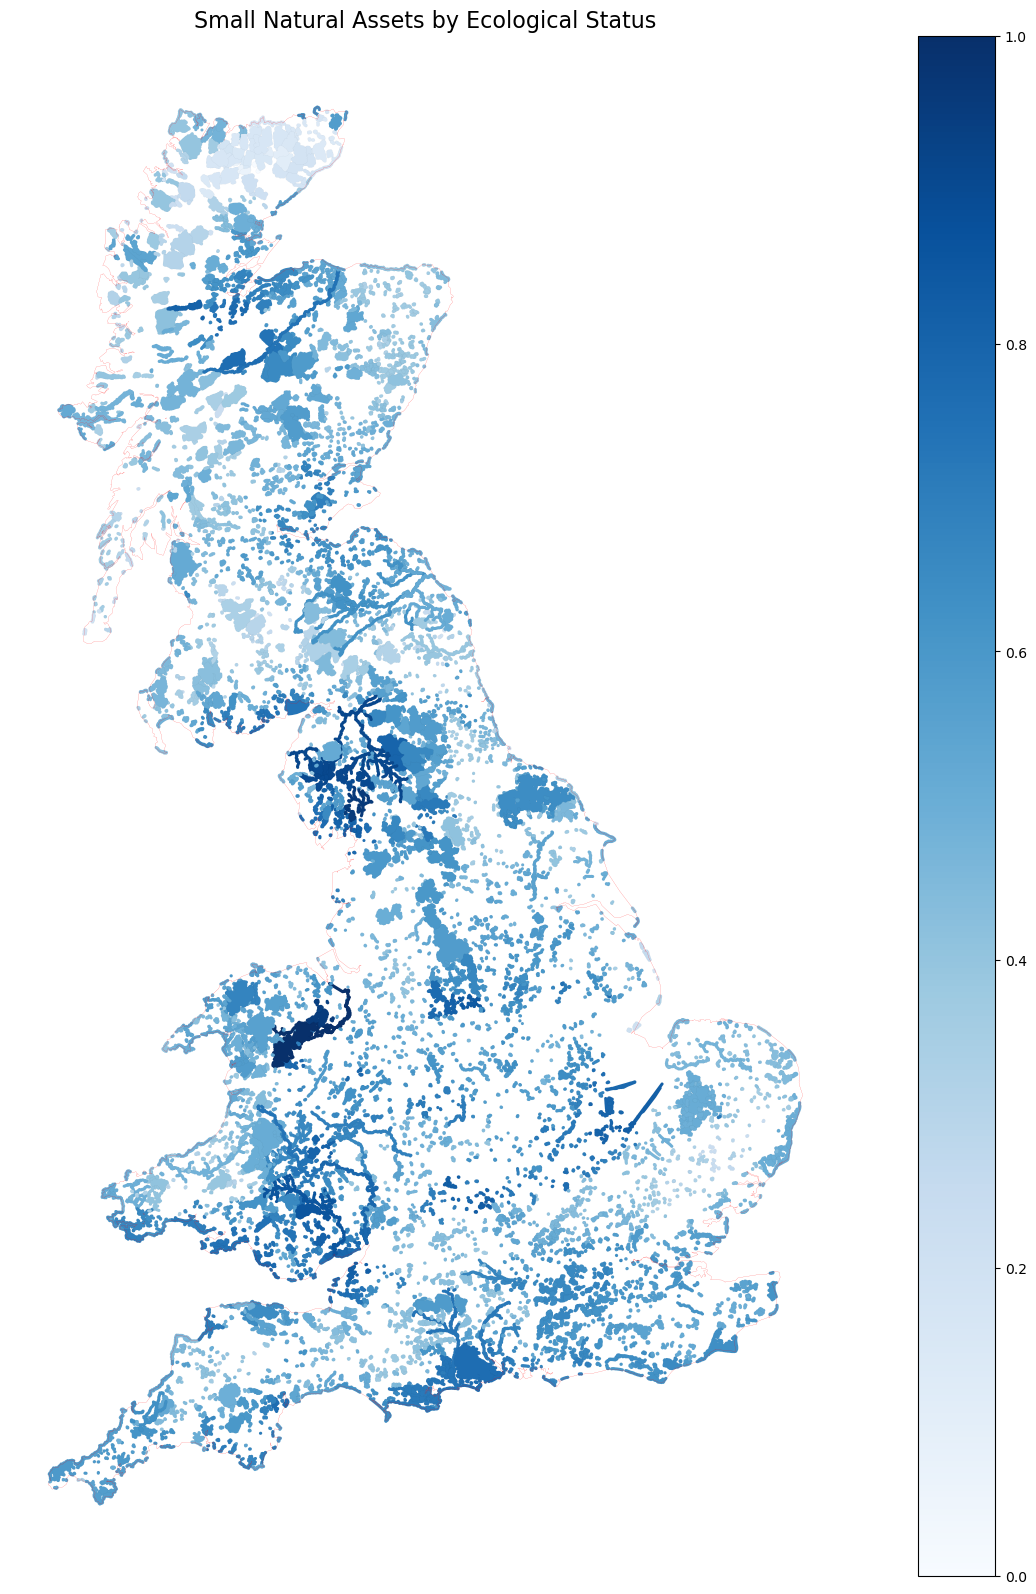

In [15]:
fig, ax = plt.subplots(figsize=(20, 20))

assets_buffered.plot(column="scaled_eco_status", ax=ax, cmap="Blues", linewidth=0.01, edgecolor="black", legend=True)
uk_largest_polygon.plot(ax=ax, facecolor="none", linewidth=0.1, edgecolor="red")

plt.title("Small Natural Assets by Ecological Status", fontsize=16)
plt.axis('off')
plt.show()

## Cycling

In [16]:
all_cycleways = gpd.read_file("natural_assets_data_raw/cycling/cycleways_combined.gpkg")
nat_cycle_network = gpd.read_file("natural_assets_data_raw/cycling/National_Cycle_Network_Public_-7383652505268944825.gpkg")

In [17]:
all_cycleways = all_cycleways[all_cycleways["geometry"].type == "LineString"]
all_cycleways = all_cycleways.to_crs("EPSG:27700").copy()
nat_cycle_network = nat_cycle_network.to_crs("EPSG:27700").copy()

In [18]:
assets_buffered = get_length_overlapped(assets_buffered, all_cycleways, target_colname="cyclepath")
assets_buffered = get_length_overlapped(assets_buffered, nat_cycle_network, target_colname="natcyclenetwork")

In [19]:
assets_buffered

,name,website,wikidata,geometry,eco_status,scaled_eco_status,cyclepath,scaled_cyclepath,natcyclenetwork,scaled_natcyclenetwork
0,Drum Sands,None,None,"POLYGON ((318019.395 677534.435, 318017.502 67...",0.858149,0.660552,6001.933167,0.119043,1081.850437,0.007460
1,Sand Bay,None,Q7415759,"POLYGON ((331981.616 165722.99, 331991.786 165...",0.938845,0.770596,0.000000,0.000000,0.000000,0.000000
2,Porth Beach,None,None,"POLYGON ((181666.434 63679.95, 181694.844 6371...",0.788513,0.565589,1340.190842,0.026582,1911.382115,0.013180
3,Watergate Beach,None,Q7974111,"POLYGON ((182408.792 64411.335, 182457.79 6450...",0.788513,0.565589,0.000000,0.000000,0.000000,0.000000
4,Mawgan Porth,None,None,"POLYGON ((183475.846 66722.47, 183461.771 6674...",0.788513,0.565589,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
7723,Ynys Uchaf,None,None,"POLYGON ((247527.749 215010.815, 247535.442 21...",0.781859,0.556516,0.000000,0.000000,0.000000,0.000000
7724,Yr Arddu,None,None,"POLYGON ((260833.889 345699.356, 260835.638 34...",0.688276,0.428897,0.000000,0.000000,0.000000,0.000000
7725,Yr Eifl,None,None,"POLYGON ((233877.113 345225.546, 233855.357 34...",0.682178,0.420581,1113.304955,0.022081,0.000000,0.000000
7726,Ysbyty Bron y Garth,None,None,"POLYGON ((259677.167 337269.011, 259586.406 33...",0.770917,0.541594,22.186149,0.000440,4057.731902,0.027981


In [75]:
cycle_columns = assets_buffered[["scaled_cyclepath", "scaled_natcyclenetwork","scaled_eco_status"]]
assets_buffered = calc_gmean_nozeros(cycle_columns, assets_buffered, "cycling_score")

Calculated geometric mean for ['scaled_cyclepath', 'scaled_natcyclenetwork', 'scaled_eco_status']


<Axes: >

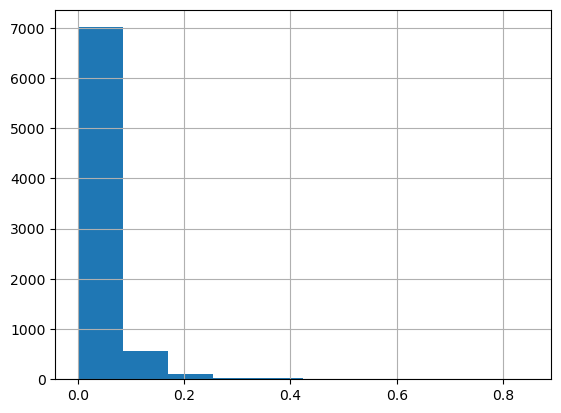

In [76]:
assets_buffered["cycling_score"].hist()

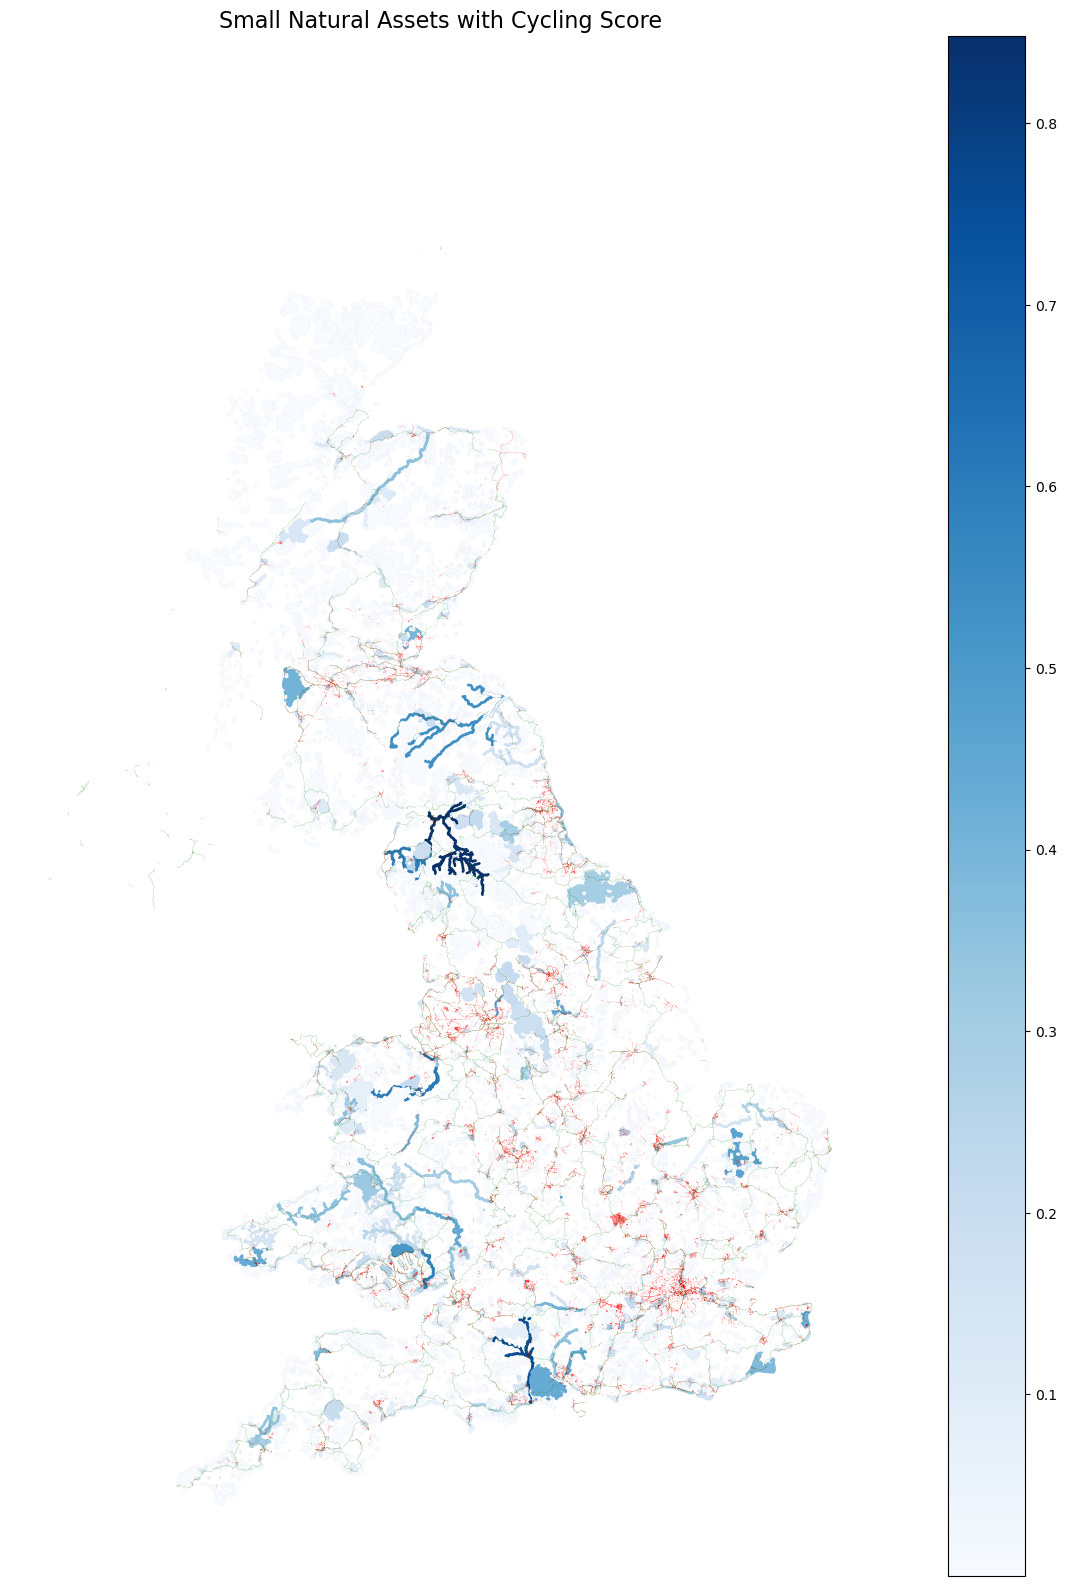

In [77]:
fig, ax = plt.subplots(figsize=(20, 20))

assets_buffered.plot(column="cycling_score", ax=ax, cmap="Blues", linewidth=0.01, edgecolor="black", legend=True)
# uk_largest_polygon.plot(ax=ax, facecolor="none", linewidth=0.5, edgecolor="grey")
all_cycleways.plot(ax=ax, edgecolor="red", linewidth=0.1)
nat_cycle_network.plot(ax=ax, edgecolor="green", linewidth=0.1)

plt.title("Small Natural Assets with Cycling Score", fontsize=16)
plt.axis('off')
plt.show()

I suggest usig hiking paths in cycling as well

## Hiking

In [23]:
trails_point = gpd.read_file("natural_assets_data_raw/trails/trails_we.shp")

In [24]:
trails_point = trails_point.to_crs("EPSG:27700").copy()
trails_point["geometry"] = trails_point.geometry.buffer(2000)

In [25]:
trails_joined = gpd.sjoin(trails_point, assets_buffered, predicate="intersects")
trails_presence = trails_joined.groupby("index_right").size()
assets_buffered["hiking_trails"] = assets_buffered.index.map(trails_presence).fillna(0).astype(int)

In [26]:
min_val, max_val = assets_buffered["hiking_trails"].min(), assets_buffered["hiking_trails"].max()
assets_buffered["scaled_hiking_trails"] = (
    (assets_buffered["hiking_trails"] - min_val) / (max_val - min_val)
    if max_val != min_val else 0
)

In [78]:
hiking_columns = assets_buffered[["scaled_hiking_trails","scaled_eco_status"]]
assets_buffered = calc_gmean_nozeros(hiking_columns, assets_buffered, "hiking_score")

Calculated geometric mean for ['scaled_hiking_trails', 'scaled_eco_status']


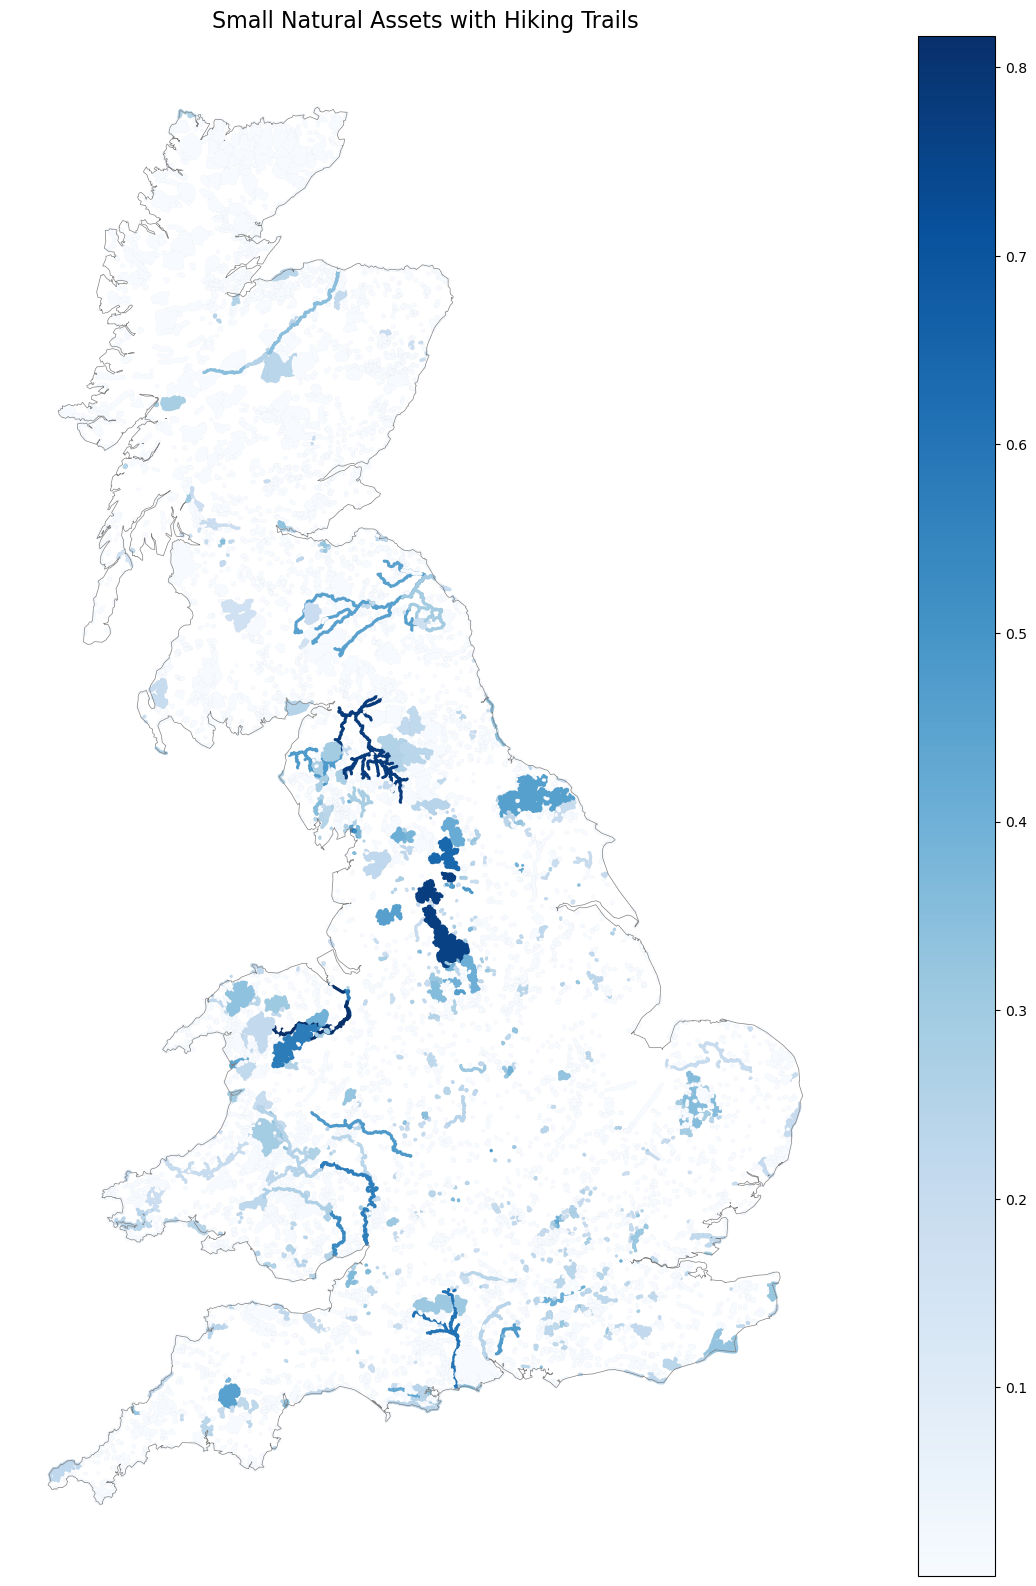

In [79]:
fig, ax = plt.subplots(figsize=(20, 20))

assets_buffered.plot(column="hiking_score", ax=ax, cmap="Blues", linewidth=0.01, edgecolor="black", legend=True)
uk_largest_polygon.plot(ax=ax, facecolor="none", linewidth=0.5, edgecolor="grey")

plt.title("Small Natural Assets with Hiking Trails", fontsize=16)
plt.axis('off')
plt.show()

## Camping

In [29]:
campsites = gpd.read_file("natural_assets_data_raw/campsites_mainland.gpkg")

In [30]:
assets_buffered = get_number_overlapped(assets_buffered, campsites, target_colname="campsites")

<Axes: >

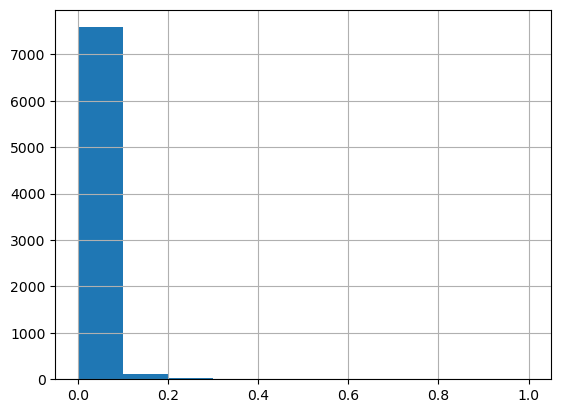

In [31]:
assets_buffered["scaled_campsites"].hist()

In [80]:
camping_columns = assets_buffered[["scaled_campsites","scaled_eco_status"]]
assets_buffered = calc_gmean_nozeros(camping_columns, assets_buffered, "camping_score")

Calculated geometric mean for ['scaled_campsites', 'scaled_eco_status']


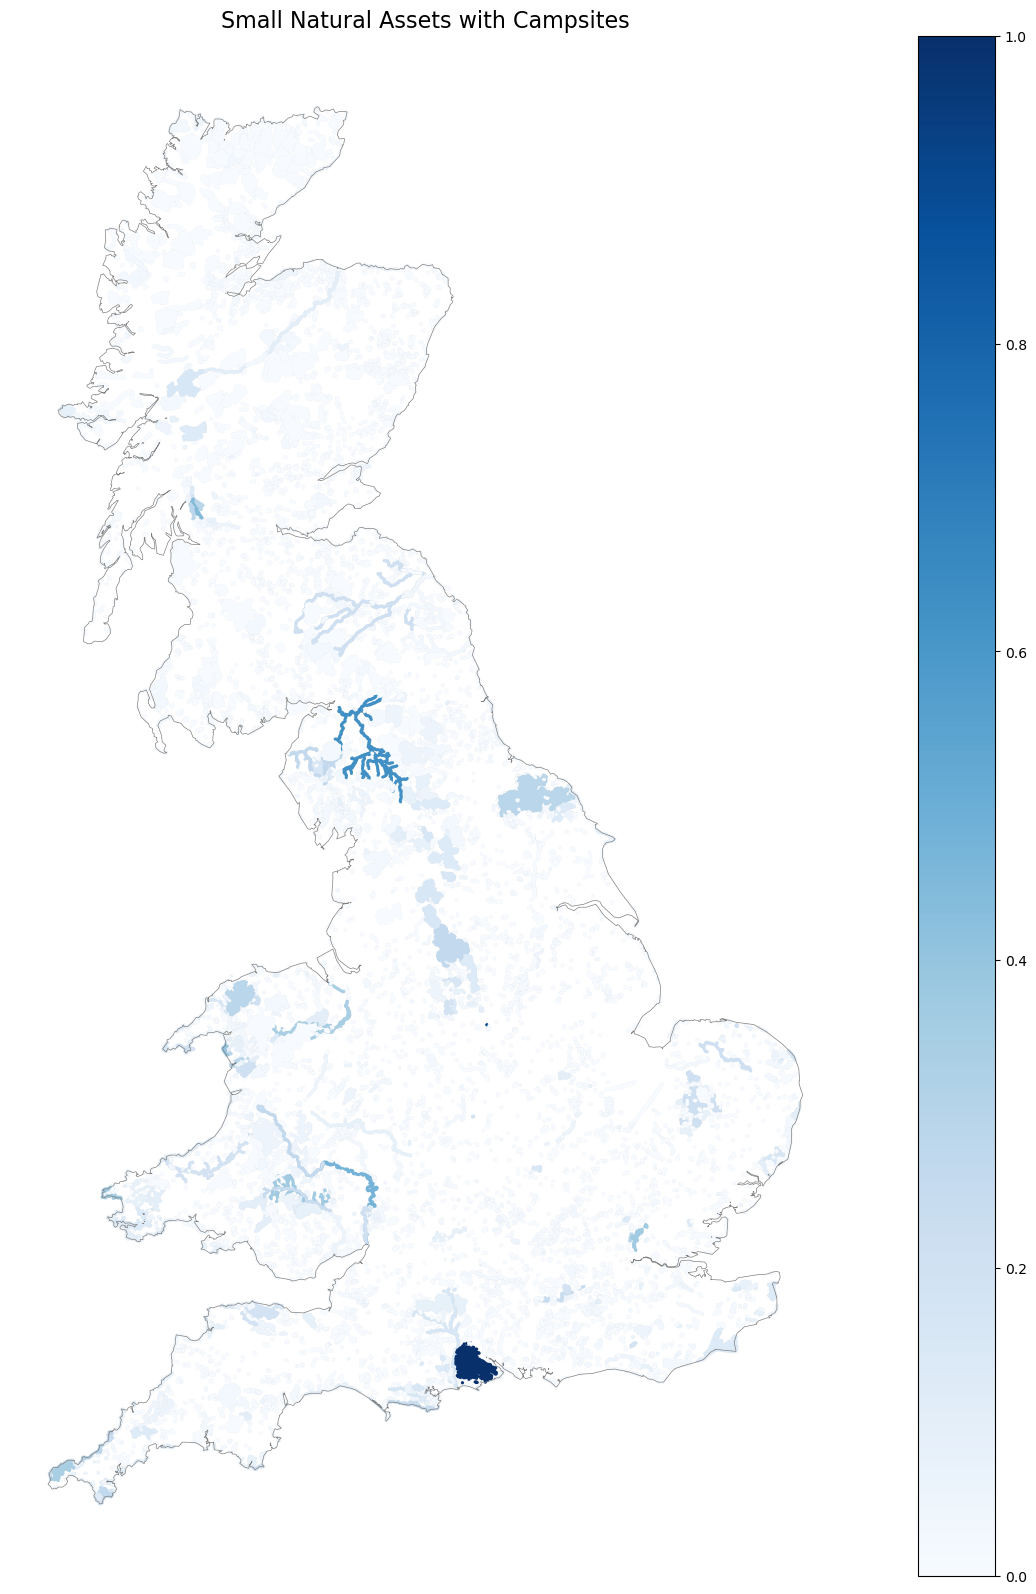

In [81]:
fig, ax = plt.subplots(figsize=(20, 20))

assets_buffered.plot(column="scaled_campsites", ax=ax, cmap="Blues", linewidth=0.01, edgecolor="black", legend=True)
uk_largest_polygon.plot(ax=ax, facecolor="none", linewidth=0.5, edgecolor="grey")

plt.title("Small Natural Assets with Campsites", fontsize=16)
plt.axis('off')
plt.show()

## Birdwatching

In [34]:
bird_sites = gpd.read_file("natural_assets_data_raw/birds/IBAs_UK_-8129902679595446195.gpkg")

/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:196: RuntimeWarning: Non-conformant content for record 1 in column AddedDate, 2012-09-06T00:00:00.0Z, successfully parsed
  return ogr_read(


In [35]:
bird_sites = bird_sites.to_crs("EPSG:27700").copy()

In [36]:
birds_joined = gpd.sjoin(bird_sites, assets_buffered, predicate="intersects")
bird_presence = birds_joined.groupby("index_right").size() > 0
assets_buffered["important_bird_area"] = assets_buffered.index.map(bird_presence).fillna(False)

In [67]:
rspb_sites = gpd.read_file("natural_assets_data_raw/birds/RSPB_Public_Reserves_-6227325677466767134.gpkg")

/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:196: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:196: RuntimeWarning: Non-conformant content for record 1 in column LastUpdate, 2022-04-01T00:00:00.0Z, successfully parsed
  return ogr_read(


In [68]:
rspb_sites = rspb_sites.to_crs("EPSG:27700").copy()

In [69]:
rspb_joined = gpd.sjoin(rspb_sites, assets_buffered, predicate="intersects")
rspb_presence = rspb_joined.groupby("index_right").size() > 0
assets_buffered["rspb_sites"] = assets_buffered.index.map(rspb_presence).fillna(False)

Now, bird sightings

In [58]:
chunksize = 10000
from collections import Counter

total_counts = Counter()

# Process each chunk
for chunk in pd.read_csv(
    'natural_assets_data_raw/birds/0000368-250424135625364.csv',
    sep="\t",
    chunksize=chunksize
):
    chunk = gpd.GeoDataFrame(chunk, geometry=gpd.points_from_xy(chunk.decimalLongitude, chunk.decimalLatitude), crs="EPSG:4326")
    chunk = chunk.to_crs(assets_buffered.crs)
   
    joined = gpd.sjoin(chunk, assets_buffered, predicate="within")
    counts = joined.groupby("index_right").size()
    
    total_counts.update(counts.to_dict())

# Convert the total counts back to a Series
total_counts_series = pd.Series(total_counts)

# Assign to dataset, filling missing values with 0
assets_buffered["bird_sightings_number"] = assets_buffered.index.map(total_counts_series).fillna(0).astype(int)

In [66]:
min_val, max_val = assets_buffered["bird_sightings_number"].min(), assets_buffered["bird_sightings_number"].max()
assets_buffered["scaled_bird_sightings_number"] = (
    (assets_buffered["bird_sightings_number"] - min_val) / (max_val - min_val)
    if max_val != min_val else 0
)

In [82]:
bird_columns = assets_buffered[["scaled_bird_sightings_number", "rspb_sites", "important_bird_area","scaled_eco_status"]]
assets_buffered = calc_gmean_nozeros(bird_columns, assets_buffered, "birdwatching_score")

Calculated geometric mean for ['scaled_bird_sightings_number', 'rspb_sites', 'important_bird_area', 'scaled_eco_status']


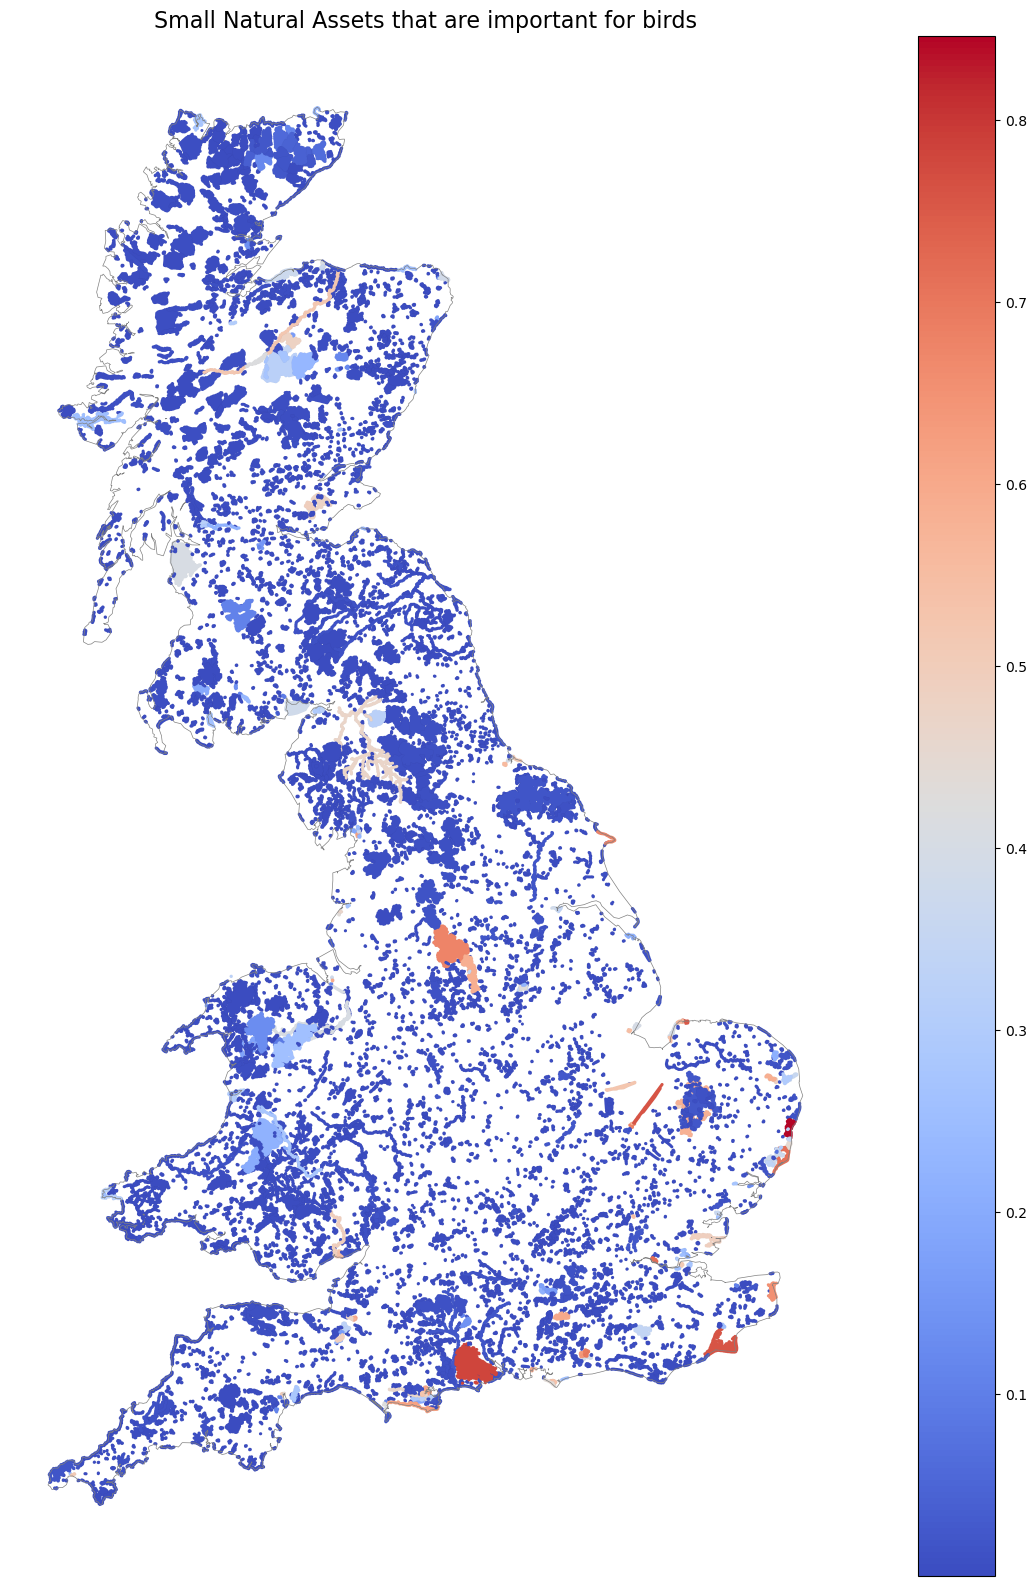

In [83]:
fig, ax = plt.subplots(figsize=(20, 20))

assets_buffered.plot(column="birdwatching_score", ax=ax, cmap="coolwarm", linewidth=0.01, edgecolor="black", legend=True)
uk_largest_polygon.plot(ax=ax, facecolor="none", linewidth=0.5, edgecolor="grey")

plt.title("Small Natural Assets that are important for birds", fontsize=16)
plt.axis('off')
plt.show()

## Beaches and Coasts

In [184]:
bathing_waters = gpd.read_file("natural_assets_data_raw/water/bathing_waters.gpkg")
coast_awards = gpd.read_file("natural_assets_data_raw/water/coast_awards_point.gpkg")
# heritage_coast = gpd.read_file("natural_assets_data_raw/water/Heritage_Coasts_England_-8361361223896276779.gpkg")
bathing_waters_england = pd.read_csv("natural_assets_data_raw/water/site.csv")
bathing_waters_wales = gpd.read_file("natural_assets_data_raw/water/nrw_bathing_waters.gpkg")

In [185]:
%%capture
bathing_waters_england["geometry"] = bathing_waters_england.apply(lambda row: Point(row["easting"], row["northing"]), axis=1)
bathing_waters_england = gpd.GeoDataFrame(bathing_waters_england, geometry="geometry")
bathing_waters_england.set_crs(epsg=27700, inplace=True)  # Change EPSG if needed (27700 = British National Grid)

In [186]:
bathing_waters = pd.concat([bathing_waters_england, bathing_waters, bathing_waters_wales], ignore_index=True)
bathing_waters = bathing_waters[["geometry"]]

bathing_joined = gpd.sjoin(bathing_waters, assets_buffered, predicate="within")
bathing_presence = bathing_joined.groupby("index_right").size() > 0
assets_buffered["bathing_waters"] = assets_buffered.index.map(bathing_presence).fillna(False)

In [187]:
# heritage_coast_joined = gpd.sjoin(heritage_coast, assets_buffered, predicate="intersects")
# heritage_coast_presence = heritage_coast_joined.groupby("index_right").size() > 0
# assets_buffered["heritage_coast"] = assets_buffered.index.map(heritage_coast_presence).fillna(False)

In [189]:
coast_awards['buffer'] = coast_awards.geometry.buffer(400)
assets_buffered['coast_award_sum'] = 0
for idx, asset in assets_buffered.iterrows():
    mask = coast_awards['buffer'].intersects(asset['geometry'])
    intersecting_points = coast_awards[mask]
    beach_award_sum = intersecting_points[['blue_flag', 'seaside_award', 'green_coast']].sum().sum()
    assets_buffered.at[idx, 'coast_award_sum'] = beach_award_sum

min_val, max_val = assets_buffered["coast_award_sum"].min(), assets_buffered["coast_award_sum"].max()
assets_buffered["scaled_coast_award_sum"] = (
    (assets_buffered["coast_award_sum"] - min_val) / (max_val - min_val)
    if max_val != min_val else 0
)

In [190]:
coast_columns = assets_buffered[["bathing_waters", "coast_award_sum","scaled_eco_status"]]
assets_buffered = calc_gmean_nozeros(coast_columns, assets_buffered, "coast_score")

Calculated geometric mean for ['bathing_waters', 'coast_award_sum', 'scaled_eco_status']


In [191]:
touches_boundary = assets_buffered.geometry.apply(lambda geom: geom.intersects(uk_largest_polygon.boundary))

In [192]:
assets_buffered["coast_score"] = assets_buffered["coast_score"] * touches_boundary[0].astype(int)

<Axes: >

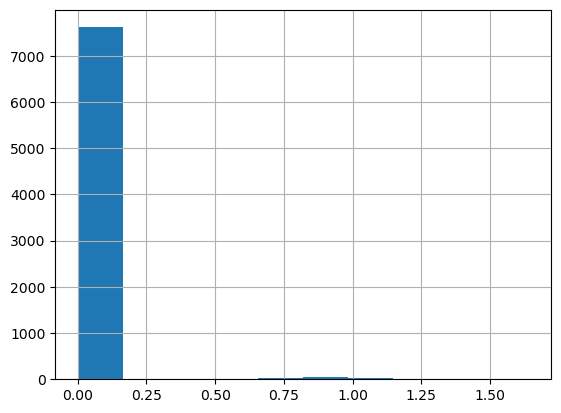

In [193]:
assets_buffered["coast_score"].hist()

In [194]:
# assets_buffered = assets_buffered.drop(columns=["bathing_waters", "heritage_coast", "coast_award_sum", "scaled_coast_award_sum", "coast_score"], axis=1)

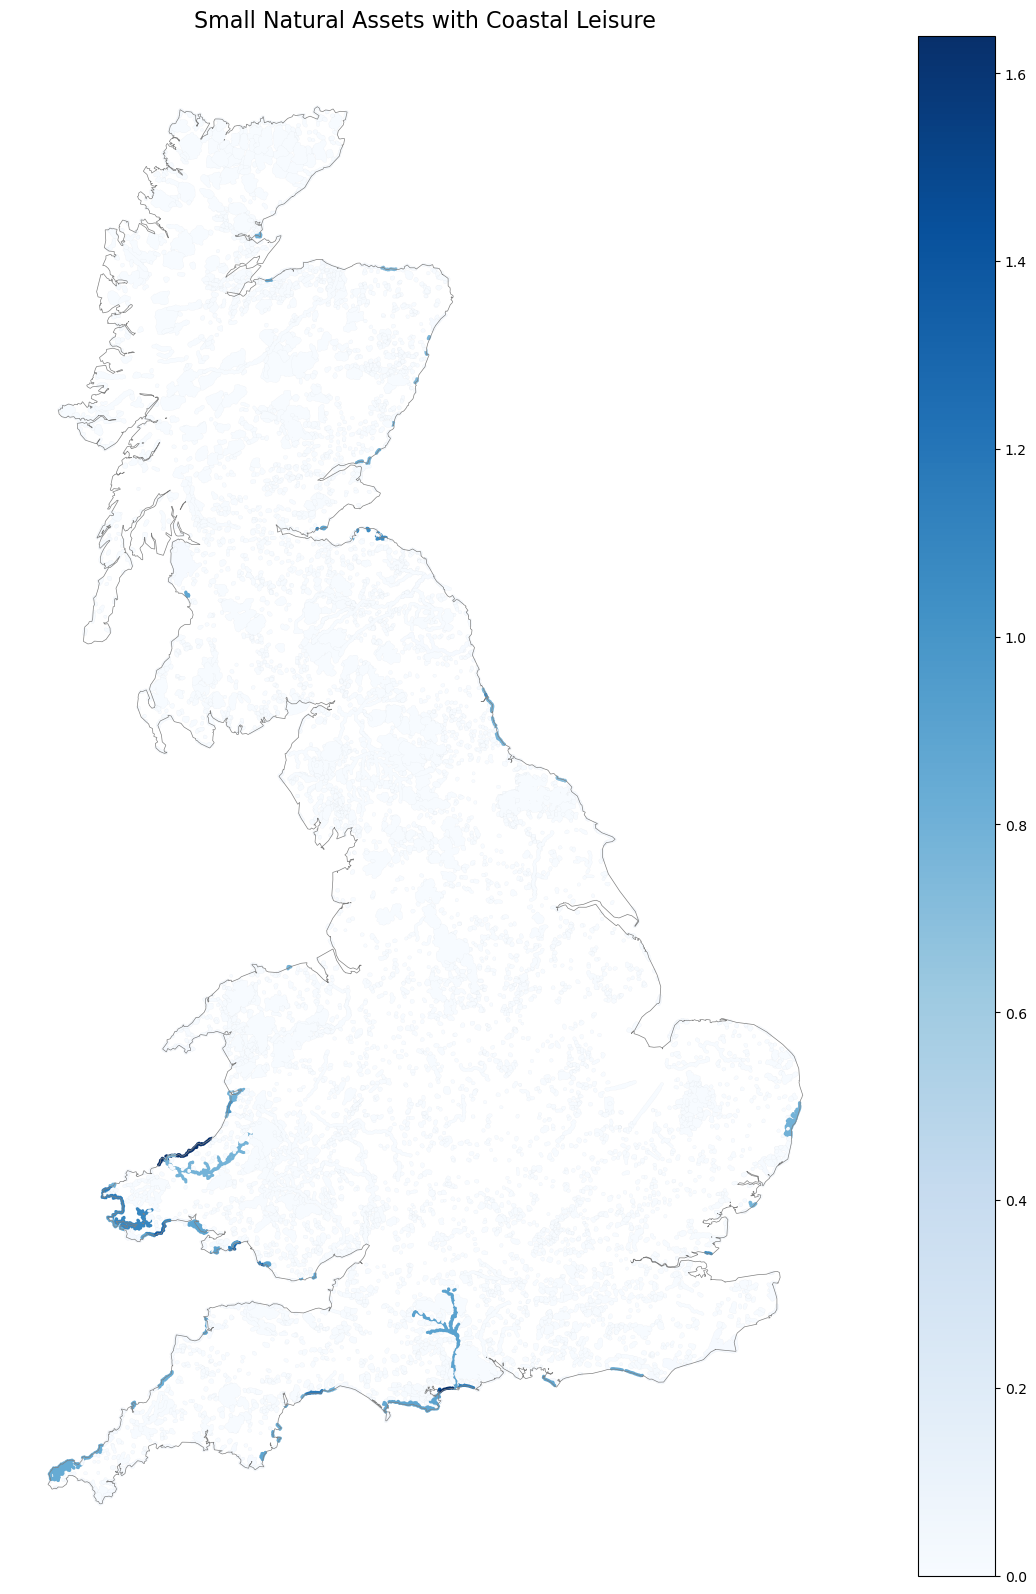

In [195]:
fig, ax = plt.subplots(figsize=(20, 20))

assets_buffered.plot(column="coast_score", ax=ax, cmap="Blues", linewidth=0.01, edgecolor="black", legend=True)
uk_largest_polygon.plot(ax=ax, facecolor="none", linewidth=0.5, edgecolor="grey")
# touches_boundary.plot(ax=ax, facecolor="green", linewidth=0.01, edgecolor="black", legend=True)

plt.title("Small Natural Assets with Coastal Leisure", fontsize=16)
plt.axis('off')
plt.show()

## Listed buildings (removed)

In [69]:
# listed_england = gpd.read_file("natural_assets_data_raw/listed/National_Heritage_List_for_England_NHLE_v02_VIEW_4825054924992358738.gpkg")
# listed_wales = gpd.read_file("natural_assets_data_raw/listed/Cadw_ListedBuildings.gpkg")
# listed_scotland = gpd.read_file("natural_assets_data_raw/listed/lb_scotland/Listed_Buildings.shp")

In [55]:
# listed_england.geometry.type.value_counts()

MultiPoint    379583
Name: count, dtype: int64

In [56]:
# grade_to_score = {"I": 3, "II*": 2, "II": 2}
# grade_to_score_scot = {"A": 3, "B": 2, "C": 1}

# listed_wales["importance_score"] = listed_wales["Grade"].map(grade_to_score).fillna(0)
# listed_england["importance_score"] = listed_england["Grade"].map(grade_to_score).fillna(0)
# listed_scotland["importance_score"] = listed_scotland["CATEGORY"].map(grade_to_score_scot).fillna(0)

In [57]:
# listed_all_uk = pd.concat([listed_england, listed_wales, listed_scotland], ignore_index=True)
# listed_all_uk = listed_all_uk[["geometry", "importance_score"]]

In [59]:
# listed_joined = gpd.sjoin(listed_all_uk, assets_buffered, predicate="within")
# import_score = listed_joined.groupby("index_right")["importance_score"].sum()
# assets_buffered["listed_bld_cumscores"] = assets_buffered.index.map(import_score).fillna(0)

# min_val, max_val = assets_buffered["listed_bld_cumscores"].min(), assets_buffered["listed_bld_cumscores"].max()
# assets_buffered["scaled_listed_bld_cumscores"] = (
#     (assets_buffered["listed_bld_cumscores"] - min_val) / (max_val - min_val)
#     if max_val != min_val else 0
# )

In [66]:
# assets_buffered["scaled_listed_bld_cumscores"].hist()

In [61]:
# assets_buffered["log_listed_bld_cumscores"] = np.log(assets_buffered["listed_bld_cumscores"] + 1)
# min_val, max_val = assets_buffered["log_listed_bld_cumscores"].min(), assets_buffered["log_listed_bld_cumscores"].max()
# assets_buffered["scaled_log_listed_bld_cumscores"] = (
#     (assets_buffered["log_listed_bld_cumscores"] - min_val) / (max_val - min_val)
#     if max_val != min_val else 0
# )

In [67]:
# assets_buffered["scaled_log_listed_bld_cumscores"].hist()

In [68]:
# fig, ax = plt.subplots(figsize=(20, 20))

# assets_buffered.plot(column="scaled_log_listed_bld_cumscores", ax=ax, cmap="Blues", linewidth=0.01, edgecolor="black", legend=True)
# uk_largest_polygon.plot(ax=ax, facecolor="none", linewidth=0.5, edgecolor="grey")

# plt.title("Small Natural Assets with Historical Significance (LOG TRANSFORMED)", fontsize=16)
# plt.axis('off')
# plt.show()

## Geology

In [265]:
georichness = gpd.read_file("natural_assets_data_raw/georichness/georichness.shp")
geomrichness = gpd.read_file("natural_assets_data_raw/georichness/geomrichness.gpkg")
litorichness = gpd.read_file("natural_assets_data_raw/georichness/litorichness.gpkg")
great_geosites = pd.read_csv("natural_assets_data_raw/georichness/great_geosites.csv")

In [266]:
great_geosites['geometry'] = [Point(xy) for xy in zip(great_geosites.Longitude, great_geosites.Latitude)]
great_geosites = great_geosites[["Location", "geometry", "Latitude", "Longitude"]]
great_geosites_gdf = gpd.GeoDataFrame(great_geosites, geometry="geometry", crs="EPSG:4326")
great_geosites_gdf = great_geosites_gdf.to_crs("EPSG:27700")

In [267]:
great_geosites_gdf

,Location,geometry,Latitude,Longitude
0,The Ironbridge Gorge,POINT (366778.713 303638.871),52.629496,-2.492253
1,Siccar Point,POINT (381249.875 670958.138),55.931316,-2.301680
2,Rotunda Museum,POINT (504322.8 488262.202),54.279382,-0.399242
3,Staffa,POINT (132430.778 735531.273),56.435821,-6.342195
4,Stonehenge,POINT (412245.86 142192.138),51.178829,-1.826183
...,...,...,...,...
95,Drumlins of Clew Bay,POINT (-106183.64 466375.522),53.845559,-9.701540
96,Borrowdale Volcanics and Crinkle Crags,POINT (324996.282 504747.884),54.432603,-3.157753
97,"Slieve Gullion, Mountains of Mourne",POINT (110417.307 478625.44),54.121694,-6.433437
98,Elgol Minor Intrusions,POINT (152456.041 814011.982),57.150010,-6.094351


In [269]:
# Buffer the geosites
great_geosites_gdf = great_geosites_gdf.buffer(1000)
great_geosites_joined = gpd.sjoin(assets_buffered, gpd.GeoDataFrame(geometry=great_geosites_gdf), predicate="intersects")
assets_buffered["great_geosite"] = False
assets_buffered.loc[great_geosites_joined.index, "great_geosite"] = True

In [204]:
georichness_joined = gpd.sjoin(georichness, assets_buffered, predicate="intersects")
georichness_max = georichness_joined.groupby("index_right")["DN"].max()
assets_buffered["georichness"] = assets_buffered.index.map(georichness_max).fillna(0)

# scale
min_val, max_val = assets_buffered["georichness"].min(), assets_buffered["georichness"].max()
assets_buffered["scaled_georichness"] = (
    (assets_buffered["georichness"] - min_val) / (max_val - min_val)
    if max_val != min_val else 0
)

In [205]:
geomrichness_joined = gpd.sjoin(geomrichness, assets_buffered, predicate="intersects")
geomrichness_max = geomrichness_joined.groupby("index_right")["DN"].max()
assets_buffered["geomrichness"] = assets_buffered.index.map(geomrichness_max).fillna(0)

# scale
min_val, max_val = assets_buffered["geomrichness"].min(), assets_buffered["geomrichness"].max()
assets_buffered["scaled_geomrichness"] = (
    (assets_buffered["geomrichness"] - min_val) / (max_val - min_val)
    if max_val != min_val else 0
)

In [206]:
litorichness_joined = gpd.sjoin(litorichness, assets_buffered, predicate="intersects")
litorichness_max = litorichness_joined.groupby("index_right")["DN"].max()
assets_buffered["litorichness"] = assets_buffered.index.map(litorichness_max).fillna(0)

# scale
min_val, max_val = assets_buffered["litorichness"].min(), assets_buffered["litorichness"].max()
assets_buffered["scaled_litorichness"] = (
    (assets_buffered["litorichness"] - min_val) / (max_val - min_val)
    if max_val != min_val else 0
)

In [277]:
geology_columns = assets_buffered[["scaled_georichness", "scaled_geomrichness","scaled_litorichness", "great_geosite"]] #scaled_eco_status excluded
assets_buffered = calc_gmean_nozeros(geology_columns, assets_buffered, "geology_score")

Calculated geometric mean for ['scaled_georichness', 'scaled_geomrichness', 'scaled_litorichness', 'great_geosite']


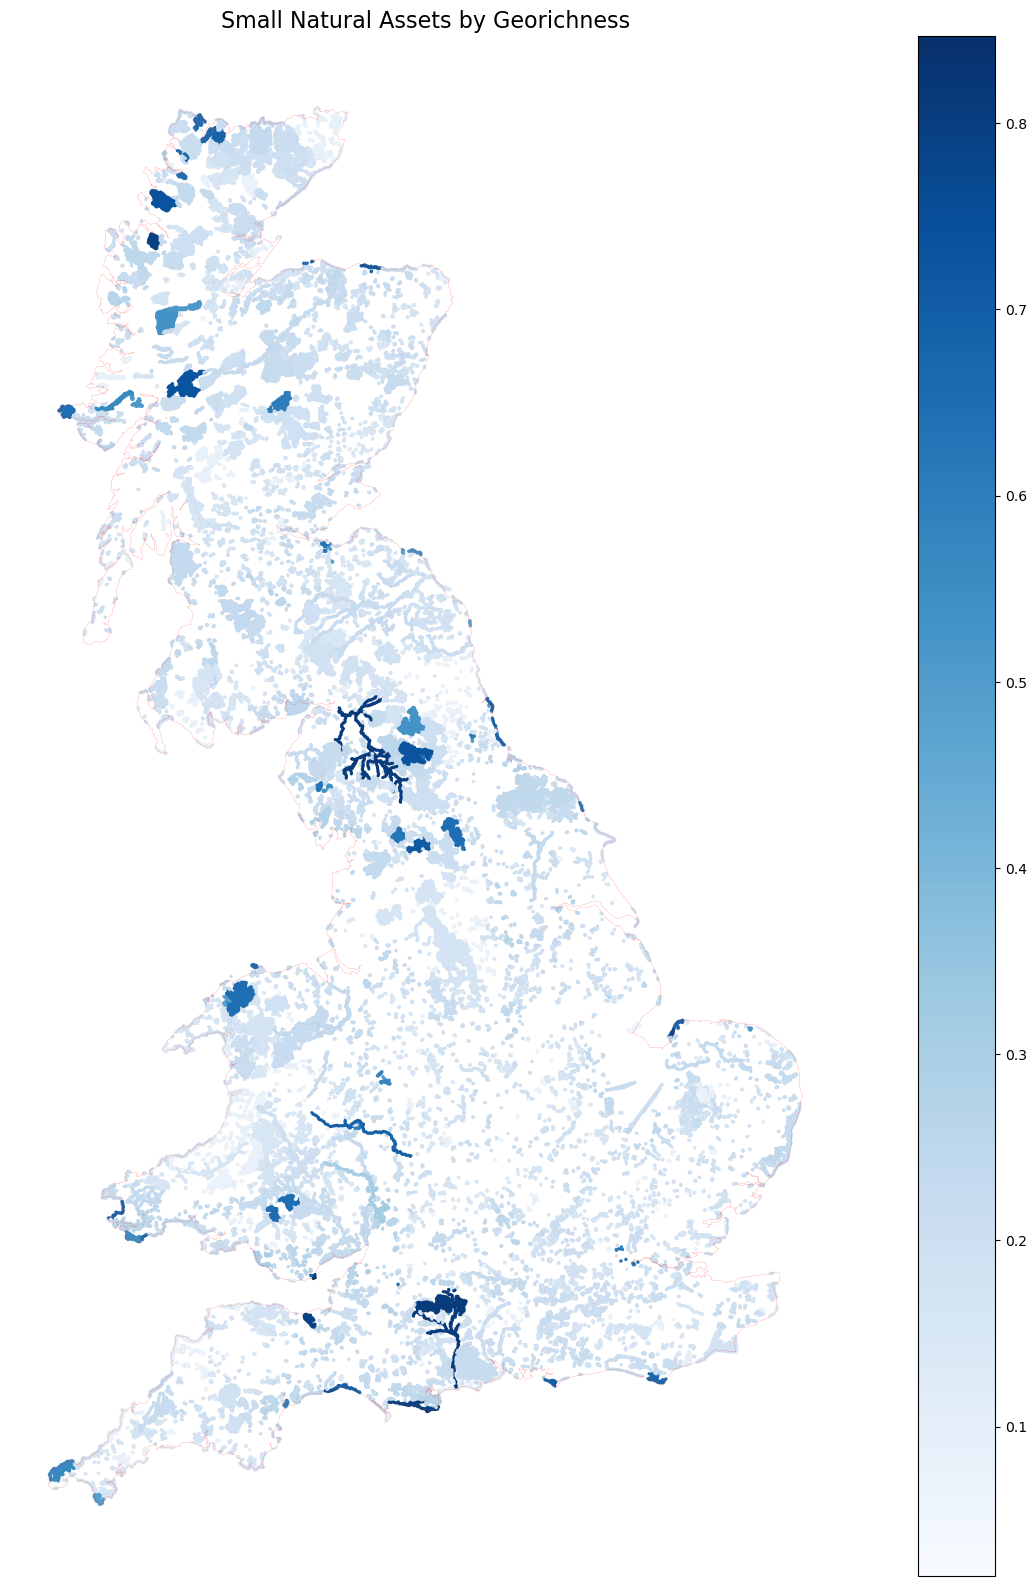

In [278]:
fig, ax = plt.subplots(figsize=(20, 20))

assets_buffered.plot(column="geology_score", ax=ax, cmap="Blues", linewidth=0.01, edgecolor="black", legend=True)
uk_largest_polygon.plot(ax=ax, facecolor="none", linewidth=0.1, edgecolor="red")

plt.title("Small Natural Assets by Georichness", fontsize=16)
plt.axis('off')
plt.show()

In [306]:
parks_dataset_iteration3 = assets_buffered.copy()
parks_dataset_iteration3["geometry"] = parks_dataset_iteration2.geometry

In [307]:
parks_dataset_iteration3["geometry"] = parks_dataset_iteration3.geometry.buffer(200, join_style="bevel")
# parks_dataset_iteration3["geometry"] = parks_dataset_iteration3.geometry.simplify(tolerance=300, preserve_topology=True)

In [313]:
import shapely

# Function to merge MultiPolygons and remove holes
def merge_and_remove_holes(geom):
    if geom.is_empty:
        return geom
    if geom.type == "MultiPolygon":
        # Merge MultiPolygon into a single polygon (dissolve boundaries)
        geom = shapely.union_all(geom)
    if geom.type == "Polygon":
        # Remove interior holes
        return shapely.geometry.Polygon(geom.exterior)
    else:
        return geom

parks_dataset_iteration3["geometry"] = parks_dataset_iteration3.geometry.apply(merge_and_remove_holes)

/tmp/ipykernel_7428/3867078870.py:7: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == "MultiPolygon":
/tmp/ipykernel_7428/3867078870.py:10: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == "Polygon":


In [314]:
parks_dataset_iteration4 = parks_dataset_iteration3.copy()
parks_dataset_iteration4["geometry"] = parks_dataset_iteration4.geometry.simplify(tolerance=100, preserve_topology=True)

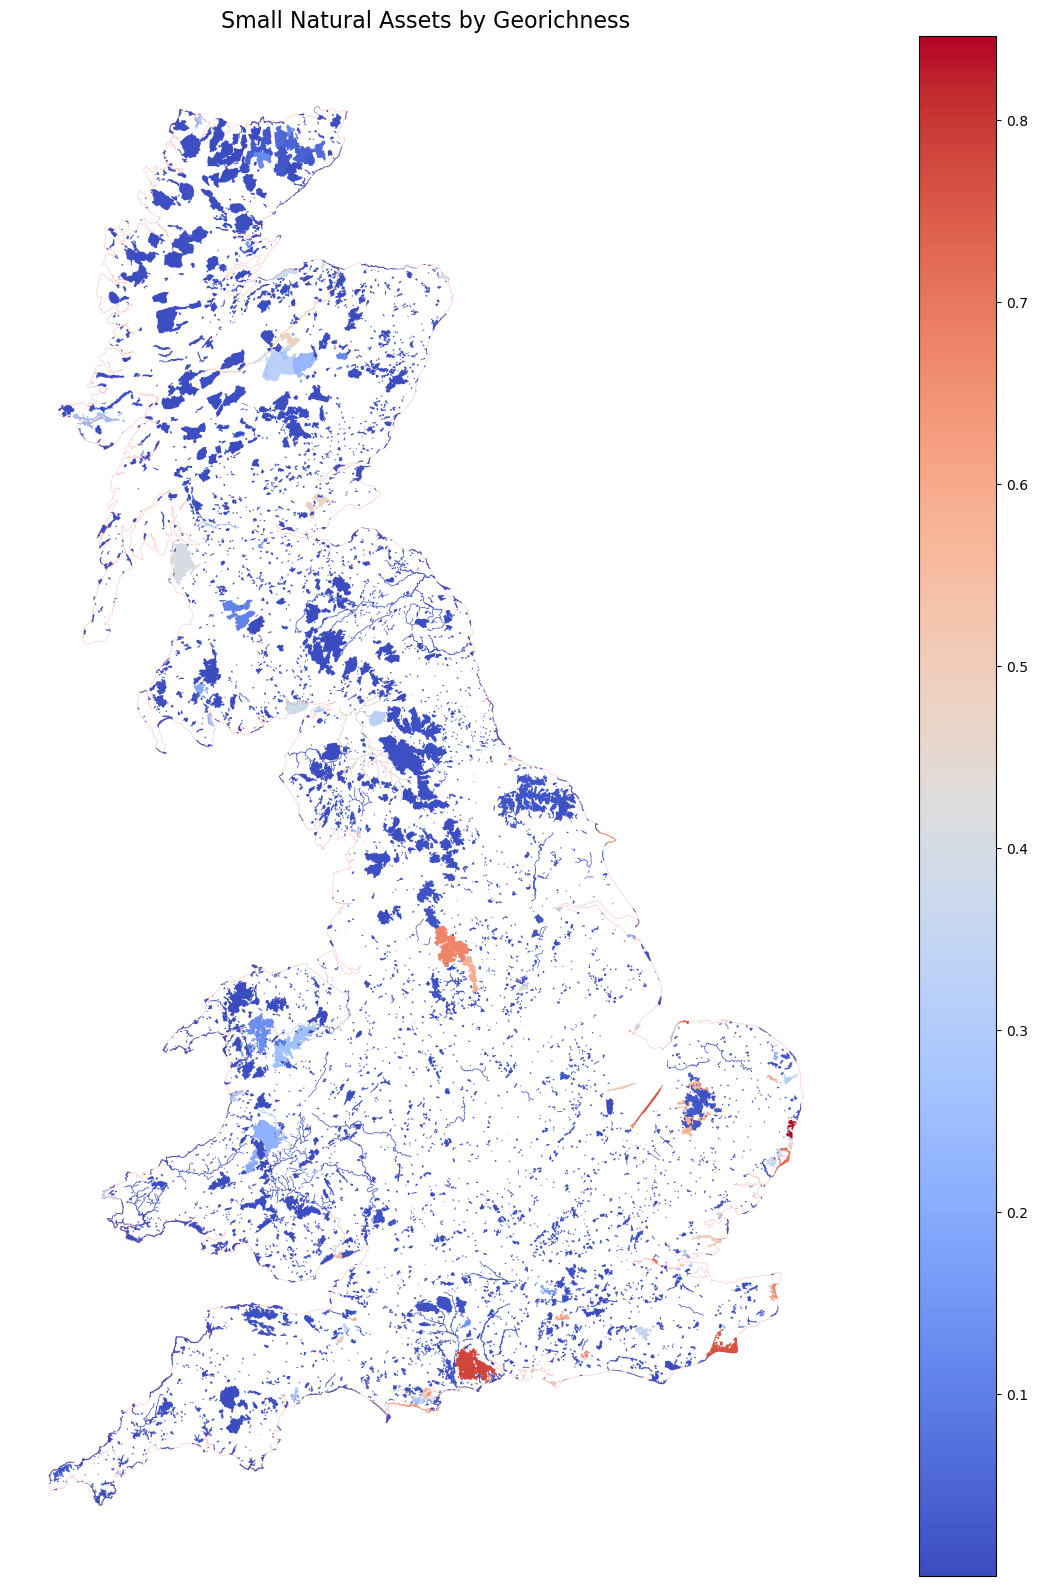

In [315]:
fig, ax = plt.subplots(figsize=(20, 20))

parks_dataset_iteration4.plot(column="birdwatching_score", ax=ax, cmap="coolwarm", linewidth=0.01, edgecolor="black", legend=True)
uk_largest_polygon.plot(ax=ax, facecolor="none", linewidth=0.1, edgecolor="red")

plt.title("Small Natural Assets by Georichness", fontsize=16)
plt.axis('off')
plt.show()

In [316]:
parks_dataset_iteration4.to_file("natural_assets_data_processed/natural_assets_2.gpkg", layer='natural_assets_2', driver="GPKG")

In [317]:
parks_dataset_iteration4

,name,website,wikidata,geometry,eco_status,scaled_eco_status,cyclepath,scaled_cyclepath,natcyclenetwork,scaled_natcyclenetwork,cycling_score,hiking_trails,scaled_hiking_trails,hiking_score,campsites,scaled_campsites,camping_score,important_bird_area,bird_sightings_number,scaled_bird_sightings_number,rspb_sites,birdwatching_score,georichness,scaled_georichness,bathing_waters,coast_award_sum,scaled_coast_award_sum,coast_score,geomrichness,scaled_geomrichness,litorichness,scaled_litorichness,geology_score,great_geosite
0,Drum Sands,None,None,"POLYGON ((319603.441 676781.191, 318793.052 67...",0.858149,0.660552,6001.933167,0.119043,1081.850437,0.007460,0.083716,0,0.0,0.000813,1.0,0.026316,0.131847,True,3532,0.045136,False,0.013140,20,0.500000,False,0,0.0,0.000087,10,1.000000,3,0.285714,0.197556,False
1,Sand Bay,None,Q7415759,"POLYGON ((332580.557 163163.144, 332936.026 16...",0.938845,0.770596,0.000000,0.000000,0.000000,0.000000,0.000092,0,0.0,0.000878,0.0,0.000000,0.000878,True,564,0.007207,False,0.008633,21,0.571429,True,0,0.0,0.009168,9,0.857143,2,0.142857,0.166617,False
2,Porth Beach,None,None,"POLYGON ((183104.703 62527.363, 182104.185 627...",0.788513,0.565589,1340.190842,0.026582,1911.382115,0.013180,0.058302,0,0.0,0.000752,1.0,0.026316,0.122002,False,47,0.000601,False,0.000136,19,0.428571,True,0,0.0,0.008270,10,1.000000,1,0.000000,0.081581,False
3,Watergate Beach,None,Q7974111,"POLYGON ((183077.216 63725.364, 183927.995 661...",0.788513,0.565589,0.000000,0.000000,0.000000,0.000000,0.000083,0,0.0,0.000752,4.0,0.105263,0.244001,False,65,0.000831,False,0.000147,19,0.428571,True,0,0.0,0.008270,10,1.000000,1,0.000000,0.081581,False
4,Mawgan Porth,None,None,"POLYGON ((184176.444 67163.511, 184379.213 680...",0.788513,0.565589,0.000000,0.000000,0.000000,0.000000,0.000083,0,0.0,0.000752,2.0,0.052632,0.172535,False,223,0.002850,False,0.000200,19,0.428571,True,0,0.0,0.008270,10,1.000000,1,0.000000,0.081581,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7723,Ynys Uchaf,None,None,"POLYGON ((248302.224 214655.049, 248447.614 21...",0.781859,0.556516,0.000000,0.000000,0.000000,0.000000,0.000082,0,0.0,0.000746,0.0,0.000000,0.000746,False,0,0.000000,False,0.000027,22,0.642857,False,0,0.0,0.000000,10,1.000000,4,0.428571,0.231897,False
7724,Yr Arddu,None,None,"POLYGON ((261643.329 345715.903, 262106.605 34...",0.688276,0.428897,0.000000,0.000000,0.000000,0.000000,0.000075,0,0.0,0.000655,0.0,0.000000,0.000655,False,142,0.001815,False,0.000167,18,0.357143,False,0,0.0,0.000000,10,1.000000,2,0.142857,0.154298,False
7725,Yr Eifl,None,None,"POLYGON ((234751.79 345351.817, 234625 345540....",0.682178,0.420581,1113.304955,0.022081,0.000000,0.000000,0.002102,0,0.0,0.000649,0.0,0.000000,0.000649,True,34,0.000434,False,0.003679,18,0.357143,False,0,0.0,0.000075,10,1.000000,2,0.142857,0.154298,False
7726,Ysbyty Bron y Garth,None,None,"POLYGON ((260270.059 338435.914, 260306.486 33...",0.770917,0.541594,22.186149,0.000440,4057.731902,0.027981,0.018837,0,0.0,0.000736,0.0,0.000000,0.000736,False,88,0.001125,False,0.000157,23,0.714286,False,0,0.0,0.000082,10,1.000000,2,0.142857,0.182864,False


In [217]:
# import geopy
# from pyproj import Proj, transform

# # Locations to geocode
# locations = [
#     "The foreland mountains, Assynt",
#     "The Ironbridge Gorge",
#     "Siccar Point",
#     "Rotunda Museum",
#     "Staffa",
#     "Stonehenge",
#     "Hunstanton Cliffs",
#     "Coast around Craster",
#     "Millook Haven",
#     "Glencoe",
#     "The Burren",
#     "Pen y Fan",
#     "Upper Teesdale",
#     "Loughareema",
#     "The Wrekin",
#     "Malham Cove",
#     "Ardnamurchan Ring Complex",
#     "Raised beach at Loch Tarbert",
#     "Lundy",
#     "Kimmeridge Bay",
#     "Allenheads Lead Mining District",
#     "Great Orme Bronze Age Mine",
#     "Geevor Tin Mine",
#     "Channel Tunnel",
#     "Farringdon Station",
#     "Dinorwig Power Station and Slate Quarry",
#     "Bath Spa",
#     "The National Mining Museum",
#     "Ludlow",
#     "Trotternish",
#     "Portrush",
#     "Schiehallion",
#     "Buchan type metamorphism, Aberdeenshire",
#     "Magnesian Limestone, South Shields",
#     "Arnaboll",
#     "Upper End of Glen Tilt",
#     "Kynance Cove",
#     "Laxford Brae road section",
#     "Natural History Museum",
#     "Granite Pluton, Isle of Arran",
#     "Knockan Crag",
#     "Wren's Nest",
#     "Our Dynamic Earth",
#     "Lyme Regis Beaches",
#     "Dinosaur Footprints, Bendrick Rock",
#     "Marble Arch Caves",
#     "Snowdon",
#     "Cuillin Hills",
#     "Gaping Gill",
#     "Porth y Ogof Caves",
#     "Mixon Hole Deep Water Gully",
#     "Uyea",
#     "St Kilda",
#     "Old Man of Hoy and St John's Head",
#     "Needles",
#     "Hadrian's Wall and Great Whin Sill",
#     "Callanish Stones",
#     "Durham Cathedral",
#     "Eddystone Lighthouse",
#     "Thames Barrier",
#     "Ceide Field Bog",
#     "Highgate Cemetery",
#     "Skara Brae",
#     "Westminster Abbey",
#     "Giant's Causeway",
#     "Lulworth",
#     "Cliffs of Moher",
#     "Seven Sisters & Beachy head",
#     "Sango Bay and Smoo Cave",
#     "Mizen Head",
#     "Achmelvich",
#     "Cliffs of Slieve League",
#     "Barafundle Bay and Stackpole Quay",
#     "Brimham Rocks",
#     "Islay, Snowball Earth Deposits",
#     "Permian Red Sandstone Cliffs, Dawlish",
#     "Scourie More",
#     "Funzie",
#     "Sub-torridonian unconformity on the Assynt Road",
#     "Sand Volcanoes near Kilkee",
#     "The Moho on the Heogs and Nikka Vord",
#     "Dalradian Marble, Maam Valley",
#     "Glencoul",
#     "The Muidhe",
#     "South Stack Formation, Anglesey",
#     "Loch Monar Polyphase Folding",
#     "Folding at Broadhaven",
#     "Outer Isles Fault and Pseudotachylytes",
#     "Cromer glacio-tectonic folds",
#     "Kilve",
#     "Clashach Moray",
#     "Cwm Idwal and Darwin's Boulders",
#     "Parallel Roads of Glen Roy",
#     "Arthur's Seat and Salisbury Crags",
#     "Drumlins of Clew Bay",
#     "Borrowdale Volcanics and Crinkle Crags",
#     "Slieve Gullion, Mountains of Mourne",
#     "Elgol Minor Intrusions",
#     "Hallival and Askival Layered Intrusions",
#     "Benbulben"
# ]

# # Create geolocator
# geolocator = geopy.Nominatim(user_agent="location_to_easting_northing")

# # Coordinate conversion functions
# wgs84 = Proj(init='epsg:4326')  # WGS84 (Lat/Lon)
# osgb36 = Proj(init='epsg:27700')  # OSGB36 (Easting/Northing)

# # List to store results
# results = []

# # Process each location
# for location in locations:
#     try:
#         # Geocode the location
#         location_data = geolocator.geocode(location, timeout=10)
        
#         if location_data:
#             # Get Latitude and Longitude
#             lat, lon = location_data.latitude, location_data.longitude
            
#             # Convert to Easting and Northing
#             easting, northing = transform(wgs84, osgb36, lon, lat)
            
#             # Append to results
#             results.append([location, lat, lon, easting, northing])
#     except Exception as e:
#         print(f"Error with {location}: {e}")

# # Convert results to DataFrame
# df = pd.DataFrame(results, columns=["Location", "Latitude", "Longitude", "Easting", "Northing"])

# # # Save to CSV
# # csv_file_path = "/mnt/data/uk_locations_easting_northing.csv"
# # df.to_csv(csv_file_path, index=False)

# # csv_file_path

/opt/conda/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/opt/conda/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_7428/3973924072.py:129: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  easting, northing = transform(wgs84, osgb36, lo

In [221]:
# new_rows = []

# for item in locations:
#     if item not in set(df["Location"]):
#         new_rows.append({'Location': item})

# # Only append once
# if new_rows:
#     df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)

In [223]:
# csv_file_path = "natural_assets_data_raw/georichness/great_geosites.csv"
# df.to_csv(csv_file_path, index=False)